### Submitted by _Vincent Barone________________

## Classification Exercise - Employee Attrition Prediction

#### Business Context
The company is experiencing high employee turnover. The HR department has asked you to build a predictive model to identify employees at risk of leaving the company.

#### Models to Compare: Baseline Models:
1. **Logistic Regression** 
2. **Decision Tree Classifier** 
3. **K-Nearest Neighbors** 

Please load `employee_attrition.csv` and predict `attrition_Yes` using the same classification models we used in the demo (i.e. logistic regression, decision tree classifier, and KNeighbor classifier). Answer the following questions and include your final code below. **When you are done, click on Run > Restart Kernel and Run All Cells... and verify the output.**

- Q1: How did you encode the categorical variables? Briefly explain why you chose this method.
- A: I chose to use get_dummies to encode the categorical variables because it is a simple way for categorical variables to be put into my models by just giving it boolean values 0 or 1 and ensures all categoircal variables are accounted for
  
- Q2. After splitting your dataset using an 80% / 20% train–test split, report the exact number of observations in the training and test sets.
- A: Training: 1176, Test: 294
  
- Q3. How many predictors (features/columns) do you have in your X dataframe after completing all cleaning and encoding steps? List any variables dropped and briefly explain why.
- A: 19 I dropped, ID because that just says who the person is and in this case I do not need that, also I dropped attrition_Yes because that is what I am predicting, so I can't use it as a predictor.
- Q4. Compare the performance of three classification models. Which model performs the best and why? Support your answer using evaluation metrics (e.g., precision, recall, f1).
- A: While Logistic Regression Model performs the best in terms of having the highest Accuracy (2.0 points higher than second place),and  precision scores (.20 better than second place) it falls short in helpful areas for the business. In terms of this business case, the decision tree would be the best model because it has the highest recall score(.30), indicating that it is best at predicting whether they actually left. Logistic Regression has a recall score of .23, meaning when it predicts that people are staying, they actually leave, which would not be helpful for the business, because the business would be losing assets when it thinks they are keeping them. Logistic Regression has the best metrics in Accuracy Precision, and F1 score (.86,.47, and .31), but the lowest recall score. The Logistic model would be the best in the sense that it scored the best in 3 out of 4 metrics, but business would possible choose the other model because it predicts recall the best.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [6]:
import warnings
warnings.filterwarnings('ignore')

In [7]:
df=pd.read_csv('employee_attrition-1.csv')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  1470 non-null   int64 
 1   age                 1470 non-null   int64 
 2   attrition           1470 non-null   object
 3   BusinessTravel      1470 non-null   object
 4   DailyRate           1470 non-null   int64 
 5   department          1470 non-null   object
 6   DistanceFromHome    1470 non-null   int64 
 7   education           1470 non-null   int64 
 8   EducationField      1470 non-null   object
 9   gender              1470 non-null   object
 10  MaritalStatus       1470 non-null   object
 11  NumCompaniesWorked  1470 non-null   int64 
 12  OverTime            1470 non-null   object
 13  TotalWorkingYears   1470 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 160.9+ KB


In [9]:
df.head()

,id,age,attrition,BusinessTravel,DailyRate,department,DistanceFromHome,education,EducationField,gender,MaritalStatus,NumCompaniesWorked,OverTime,TotalWorkingYears
0,1,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,Female,Single,8,Yes,8
1,2,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,Male,Married,1,No,10
2,3,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,Male,Single,6,Yes,7
3,4,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,Female,Married,1,Yes,8
4,5,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,Male,Married,9,No,6


In [10]:
cat_cols=df.select_dtypes('object')
for i in cat_cols:
    print(df[i].value_counts())
    print('*'*40)

attrition
No     1233
Yes     237
Name: count, dtype: int64
****************************************
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
****************************************
department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64
****************************************
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64
****************************************
gender
Male      882
Female    588
Name: count, dtype: int64
****************************************
MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64
****************************************
OverTime
No     1054
Yes     416
Name: count, dtype: int64
****************************************


In [11]:
corr_mat=df.select_dtypes('number').corr().round(2)

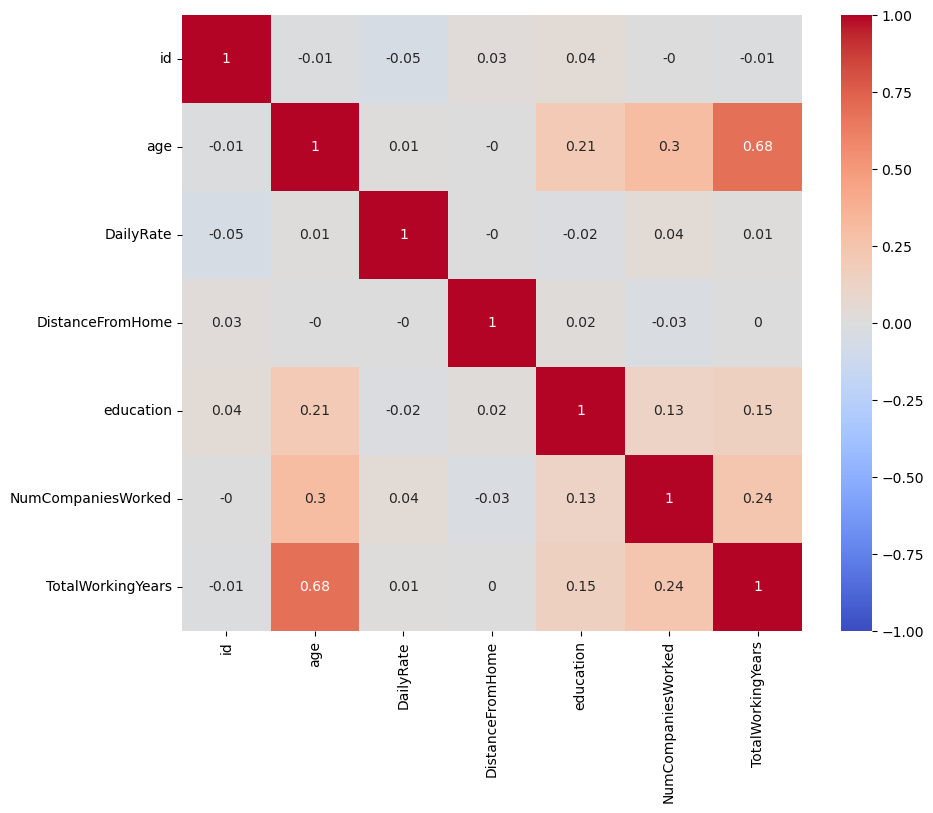

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', vmin=-1, center=0, vmax=1)
plt.show()

In [13]:
df.isna().sum()

id                    0
age                   0
attrition             0
BusinessTravel        0
DailyRate             0
department            0
DistanceFromHome      0
education             0
EducationField        0
gender                0
MaritalStatus         0
NumCompaniesWorked    0
OverTime              0
TotalWorkingYears     0
dtype: int64

In [14]:
df=df.dropna()

In [15]:
df.duplicated().sum()

0

In [16]:
df=pd.get_dummies(df,drop_first=True)

In [17]:
df.head(2)

,id,age,DailyRate,DistanceFromHome,education,NumCompaniesWorked,TotalWorkingYears,attrition_Yes,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,...,department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,gender_Male,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,1,41,1102,1,2,8,8,True,False,True,...,True,True,False,False,False,False,False,False,True,True
1,2,49,279,8,1,1,10,False,True,False,...,False,True,False,False,False,False,True,True,False,False


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   id                                 1470 non-null   int64
 1   age                                1470 non-null   int64
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   education                          1470 non-null   int64
 5   NumCompaniesWorked                 1470 non-null   int64
 6   TotalWorkingYears                  1470 non-null   int64
 7   attrition_Yes                      1470 non-null   bool 
 8   BusinessTravel_Travel_Frequently   1470 non-null   bool 
 9   BusinessTravel_Travel_Rarely       1470 non-null   bool 
 10  department_Research & Development  1470 non-null   bool 
 11  department_Sales                   1470 non-null   bool 
 12  EducationField_Life 

In [19]:
y=df['attrition_Yes']

In [20]:
y.shape

(1470,)

In [21]:
X=df.drop(columns=['attrition_Yes','id'])

In [22]:
X.shape

(1470, 19)

In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   age                                1470 non-null   int64
 1   DailyRate                          1470 non-null   int64
 2   DistanceFromHome                   1470 non-null   int64
 3   education                          1470 non-null   int64
 4   NumCompaniesWorked                 1470 non-null   int64
 5   TotalWorkingYears                  1470 non-null   int64
 6   BusinessTravel_Travel_Frequently   1470 non-null   bool 
 7   BusinessTravel_Travel_Rarely       1470 non-null   bool 
 8   department_Research & Development  1470 non-null   bool 
 9   department_Sales                   1470 non-null   bool 
 10  EducationField_Life Sciences       1470 non-null   bool 
 11  EducationField_Marketing           1470 non-null   bool 
 12  EducationField_Medic

In [25]:
for_scaler=X.iloc[:,0:6]

In [26]:
for_scaler.shape

(1470, 6)

In [27]:
scaled =StandardScaler().fit_transform(for_scaler)

In [28]:
X.iloc[:, 0:6]=scaled

In [29]:
X.head()

,age,DailyRate,DistanceFromHome,education,NumCompaniesWorked,TotalWorkingYears,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,department_Research & Development,department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,gender_Male,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,2.125136,-0.421642,False,True,False,True,True,False,False,False,False,False,False,True,True
1,1.322365,-1.297775,-0.147150,-1.868426,-0.678049,-0.164511,True,False,True,False,True,False,False,False,False,True,True,False,False
2,0.008343,1.414363,-0.887515,-0.891688,1.324226,-0.550208,False,True,True,False,False,False,False,True,False,True,False,True,True
3,-0.429664,1.461466,-0.764121,1.061787,-0.678049,-0.421642,True,False,True,False,True,False,False,False,False,False,True,False,True
4,-1.086676,-0.524295,-0.887515,-1.868426,2.525591,-0.678774,False,True,True,False,False,False,True,False,False,True,True,False,False


In [30]:
from sklearn.model_selection import train_test_split

In [108]:
X_train,X_test,y_train, y_test = train_test_split(X,y,test_size=.2,random_state=42)

In [110]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1176, 19)
(294, 19)
(1176,)
(294,)


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [34]:
log = LogisticRegression()

In [35]:
# fit model on train data 
log.fit(X_train, y_train)

LogisticRegression()

In [36]:
pred_log=log.predict(X_test)

In [37]:
pred_log

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False,  True,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True,  True,
       False, False,

In [38]:
dtc = DecisionTreeClassifier()

In [39]:
dtc.fit(X_train,y_train)

DecisionTreeClassifier()

In [40]:
pred_dtc=dtc.predict(X_test)

In [41]:
pred_dtc

array([False, False,  True, False, False, False, False, False, False,
       False,  True, False, False, False, False, False,  True, False,
       False, False, False, False,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False,  True,
       False, False, False,  True,  True, False, False, False, False,
       False,  True,  True, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True, False, False, False, False, False,
       False,  True, False, False, False, False, False, False,  True,
        True, False,  True, False, False, False, False, False, False,
       False, False, False, False, False,  True, False, False, False,
       False, False,

In [42]:
knc = KNeighborsClassifier()

In [43]:
knc.fit(X_train,y_train)

KNeighborsClassifier()

In [44]:
pred_knc=knc.predict(X_test)

In [45]:
pred_knc

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
       False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False,

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score 

In [47]:
accuracy_log=accuracy_score(y_test, pred_log)
precision_log=precision_score(y_test, pred_log)
recall_log=recall_score(y_test, pred_log)
f1_log=f1_score(y_test, pred_log)

In [48]:
pm_log=pd.DataFrame({'Accuracy':[accuracy_log],'Precision':[precision_log],'Recall':[recall_log],'F1':[f1_log]},index=['Logistic Regression'])

In [49]:
accuracy_dtc=accuracy_score(y_test, pred_dtc)
precision_dtc=precision_score(y_test, pred_dtc)
recall_dtc=recall_score(y_test, pred_dtc)
f1_dtc=f1_score(y_test, pred_dtc)

In [50]:
pm_dtc=pd.DataFrame({'Accuracy':[accuracy_dtc],'Precision':[precision_dtc],'Recall':[recall_dtc],'F1':[f1_dtc]},index=['Decision Tree'])

In [51]:
accuracy_knc=accuracy_score(y_test, pred_knc)
precision_knc=precision_score(y_test, pred_knc)
recall_knc=recall_score(y_test, pred_knc)
f1_knc=f1_score(y_test, pred_knc)

In [52]:
pm_knc=pd.DataFrame({'Accuracy':[accuracy_knc],'Precision':[precision_knc],'Recall':[recall_knc],'F1':[f1_knc]},index=['Kneighors'])

In [53]:
performance=pd.concat([pm_log,pm_dtc,pm_knc])

In [54]:
performance

,Accuracy,Precision,Recall,F1
Logistic Regression,0.863946,0.473684,0.230769,0.310345
Decision Tree,0.792517,0.260870,0.307692,0.282353
Kneighors,0.843537,0.230769,0.076923,0.115385
